# IMC Prosperity 4 — Round 1 Data Analysis
Products: **ASH_COATED_OSMIUM (ACO)** and **INTARIAN_PEPPER_ROOT (IPR)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy import stats

DATA = Path('data')
DAYS = [-2, -1, 0]
PRODUCTS = ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']
SHORT = {'ASH_COATED_OSMIUM': 'ACO', 'INTARIAN_PEPPER_ROOT': 'IPR'}
COLORS = {'ASH_COATED_OSMIUM': '#2196F3', 'INTARIAN_PEPPER_ROOT': '#FF5722'}

# ── load all price data ──────────────────────────────────────────────────────
price_frames = []
for d in DAYS:
    df = pd.read_csv(DATA / f'prices_round_1_day_{d}.csv', sep=';')
    df['day'] = d
    # absolute timestamp across days
    df['abs_ts'] = (d + 2) * 1_000_000 + df['timestamp']
    price_frames.append(df)
prices = pd.concat(price_frames, ignore_index=True)
prices = prices[prices['mid_price'] > 0]   # drop sparse rows with no mid

# ── load all trade data ──────────────────────────────────────────────────────
trade_frames = []
for d in DAYS:
    df = pd.read_csv(DATA / f'trades_round_1_day_{d}.csv', sep=';')
    df['day'] = d
    df['abs_ts'] = (d + 2) * 1_000_000 + df['timestamp']
    trade_frames.append(df)
trades = pd.concat(trade_frames, ignore_index=True)

print(f'Price rows: {len(prices):,}   Trade rows: {len(trades):,}')
prices.head(3)

Price rows: 59,897   Trade rows: 2,276


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,abs_ts
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,100


## 1. Mid-price time series — all 3 days

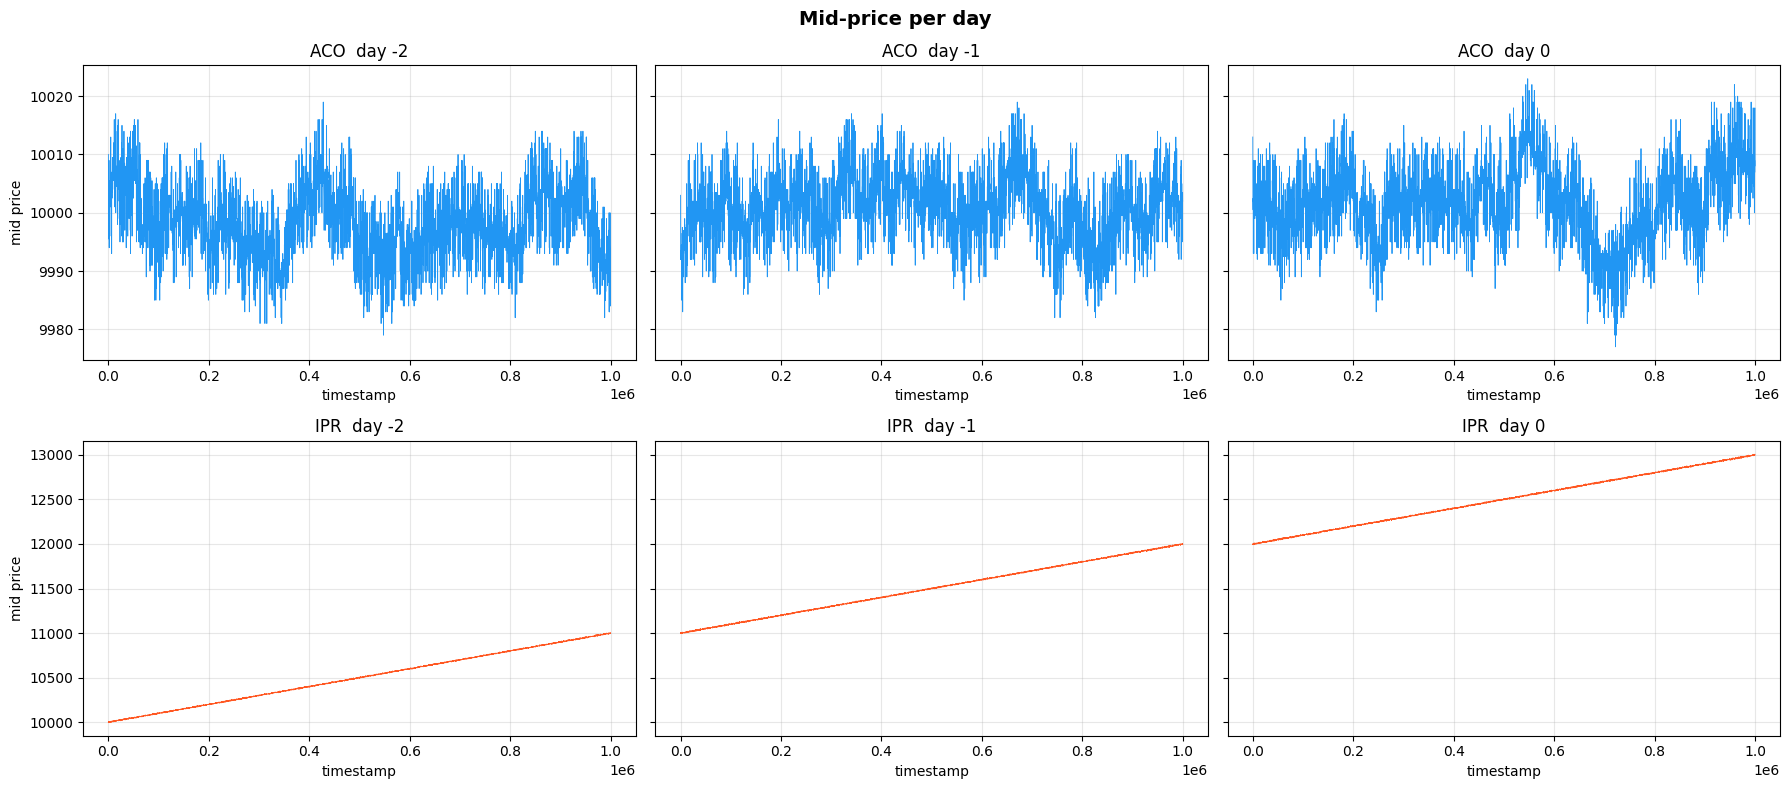

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey='row')
fig.suptitle('Mid-price per day', fontsize=14, fontweight='bold')

for row, prod in enumerate(PRODUCTS):
    for col, day in enumerate(DAYS):
        ax = axes[row][col]
        sub = prices[(prices['product'] == prod) & (prices['day'] == day)]
        ax.plot(sub['timestamp'], sub['mid_price'], color=COLORS[prod], lw=0.6)
        ax.set_title(f'{SHORT[prod]}  day {day}')
        ax.set_xlabel('timestamp')
        if col == 0:
            ax.set_ylabel('mid price')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mid_price_series.png', dpi=150)
plt.show()

## 2. ACO — is there a stable fair value?

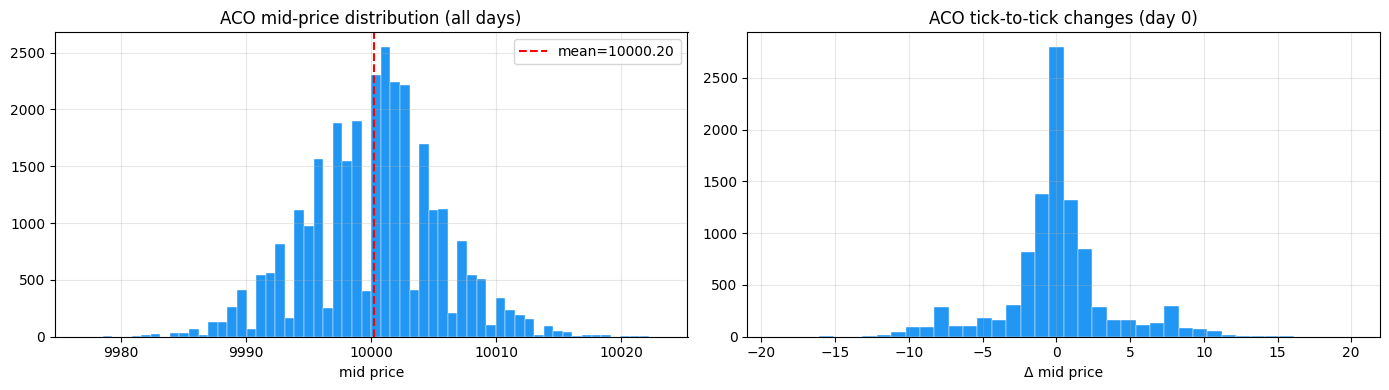

ACO stats (all days):
  mean  = 10000.2042
  std   = 5.3497
  min   = 9977.0
  max   = 10023.0
  range = 46.0
  day -2: mean=9998.170  std=5.220
  day -1: mean=10000.834  std=4.450
  day 0: mean=10001.608  std=5.684


In [3]:
aco = prices[prices['product'] == 'ASH_COATED_OSMIUM'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# histogram of mid prices
axes[0].hist(aco['mid_price'], bins=60, color=COLORS['ASH_COATED_OSMIUM'], edgecolor='white', linewidth=0.3)
axes[0].axvline(aco['mid_price'].mean(), color='red', linestyle='--', label=f"mean={aco['mid_price'].mean():.2f}")
axes[0].set_title('ACO mid-price distribution (all days)')
axes[0].set_xlabel('mid price')
axes[0].legend()
axes[0].grid(alpha=0.3)

# tick-by-tick changes
aco_day0 = aco[aco['day'] == 0].copy()
aco_day0['delta'] = aco_day0['mid_price'].diff()
axes[1].hist(aco_day0['delta'].dropna(), bins=40, color=COLORS['ASH_COATED_OSMIUM'], edgecolor='white', linewidth=0.3)
axes[1].set_title('ACO tick-to-tick changes (day 0)')
axes[1].set_xlabel('Δ mid price')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('aco_distribution.png', dpi=150)
plt.show()

print(f"ACO stats (all days):")
print(f"  mean  = {aco['mid_price'].mean():.4f}")
print(f"  std   = {aco['mid_price'].std():.4f}")
print(f"  min   = {aco['mid_price'].min():.1f}")
print(f"  max   = {aco['mid_price'].max():.1f}")
print(f"  range = {aco['mid_price'].max() - aco['mid_price'].min():.1f}")
for d in DAYS:
    s = aco[aco['day']==d]['mid_price']
    print(f"  day {d}: mean={s.mean():.3f}  std={s.std():.3f}")

## 3. IPR — trending or mean-reverting?

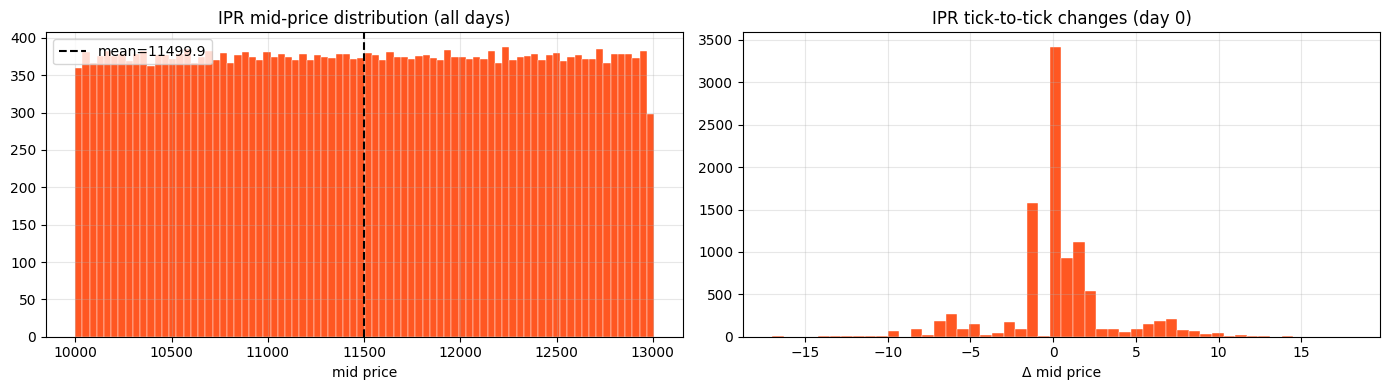

IPR stats (all days):
  mean  = 11499.8885
  std   = 866.1071
  range = 3008.5
  day -2: mean=10499.964  std=288.722  min=9998.5  max=11003.0
  day -1: mean=11500.030  std=288.669  min=10995.0  max=12006.0
  day 0: mean=12500.173  std=288.731  min=11994.0  max=13007.0


In [4]:
ipr = prices[prices['product'] == 'INTARIAN_PEPPER_ROOT'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(ipr['mid_price'], bins=80, color=COLORS['INTARIAN_PEPPER_ROOT'], edgecolor='white', linewidth=0.3)
axes[0].axvline(ipr['mid_price'].mean(), color='black', linestyle='--', label=f"mean={ipr['mid_price'].mean():.1f}")
axes[0].set_title('IPR mid-price distribution (all days)')
axes[0].set_xlabel('mid price')
axes[0].legend()
axes[0].grid(alpha=0.3)

ipr_day0 = ipr[ipr['day'] == 0].copy()
ipr_day0['delta'] = ipr_day0['mid_price'].diff()
axes[1].hist(ipr_day0['delta'].dropna(), bins=50, color=COLORS['INTARIAN_PEPPER_ROOT'], edgecolor='white', linewidth=0.3)
axes[1].set_title('IPR tick-to-tick changes (day 0)')
axes[1].set_xlabel('Δ mid price')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ipr_distribution.png', dpi=150)
plt.show()

print(f"IPR stats (all days):")
print(f"  mean  = {ipr['mid_price'].mean():.4f}")
print(f"  std   = {ipr['mid_price'].std():.4f}")
print(f"  range = {ipr['mid_price'].max() - ipr['mid_price'].min():.1f}")
for d in DAYS:
    s = ipr[ipr['day']==d]['mid_price']
    print(f"  day {d}: mean={s.mean():.3f}  std={s.std():.3f}  min={s.min():.1f}  max={s.max():.1f}")

## 4. Autocorrelation of mid-price changes (mean-reversion test)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, prod in zip(axes, PRODUCTS):
    sub = prices[(prices['product'] == prod) & (prices['day'] == 0)].copy()
    deltas = sub['mid_price'].diff().dropna()
    lags = range(1, 31)
    acf = [deltas.autocorr(lag=l) for l in lags]
    bars = ax.bar(lags, acf, color=COLORS[prod], alpha=0.8)
    # 95% confidence band
    ci = 1.96 / np.sqrt(len(deltas))
    ax.axhline(ci,  color='red', linestyle='--', linewidth=0.8, label='95% CI')
    ax.axhline(-ci, color='red', linestyle='--', linewidth=0.8)
    ax.axhline(0,   color='black', linewidth=0.5)
    ax.set_title(f'{SHORT[prod]} — ACF of Δmid (day 0)')
    ax.set_xlabel('lag (ticks)')
    ax.set_ylabel('autocorrelation')
    ax.legend()
    ax.grid(alpha=0.3)
    print(f"{SHORT[prod]} lag-1 autocorr = {deltas.autocorr(lag=1):.4f}")

plt.tight_layout()
plt.savefig('autocorrelation.png', dpi=150)
plt.show()

## 5. Bid-ask spread analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, prod in zip(axes, PRODUCTS):
    sub = prices[(prices['product'] == prod) & (prices['bid_price_1'] > 0) & (prices['ask_price_1'] > 0)].copy()
    sub['spread'] = sub['ask_price_1'] - sub['bid_price_1']
    ax.hist(sub['spread'], bins=30, color=COLORS[prod], edgecolor='white', linewidth=0.3)
    ax.axvline(sub['spread'].mean(), color='black', linestyle='--',
               label=f"mean={sub['spread'].mean():.2f}")
    ax.set_title(f'{SHORT[prod]} best bid-ask spread')
    ax.set_xlabel('spread (ticks)')
    ax.legend()
    ax.grid(alpha=0.3)
    print(f"{SHORT[prod]} spread:  mean={sub['spread'].mean():.2f}  median={sub['spread'].median():.1f}  "
          f"min={sub['spread'].min():.0f}  max={sub['spread'].max():.0f}")

plt.tight_layout()
plt.savefig('spread_distribution.png', dpi=150)
plt.show()

## 6. Order book depth

In [ ]:
for prod in PRODUCTS:
    sub = prices[(prices['product'] == prod) & (prices['day'] == 0)]
    print(f"\n{SHORT[prod]} — order book depth (day 0):")
    for side, levels in [('BID', ['bid_volume_1','bid_volume_2','bid_volume_3']),
                          ('ASK', ['ask_volume_1','ask_volume_2','ask_volume_3'])]:
        for lv in levels:
            col = sub[lv].replace(0, np.nan).dropna()
            if len(col) > 0:
                print(f"  {side} {lv[-1]}: present {len(col)/len(sub)*100:.1f}% of ticks,  "
                      f"avg size={col.mean():.1f}  max={col.max():.0f}")

## 7. Trade flow — who are the bots?

In [ ]:
for prod in PRODUCTS:
    sub = trades[trades['symbol'] == prod]
    print(f"\n{'='*50}")
    print(f"{SHORT[prod]}  —  {len(sub)} trades total")
    # who are the counterparties?
    buyers  = sub['buyer'].value_counts()
    sellers = sub['seller'].value_counts()
    all_bots = pd.concat([buyers, sellers]).groupby(level=0).sum().sort_values(ascending=False)
    print("Top counterparties (combined buyer+seller appearances):")
    print(all_bots.head(10).to_string())
    print(f"\nTrade size:  mean={sub['quantity'].mean():.1f}  median={sub['quantity'].median():.0f}  "
          f"max={sub['quantity'].max():.0f}")
    print(f"Trade price: mean={sub['price'].mean():.2f}  std={sub['price'].std():.2f}")

## 8. Trade price vs mid price — are bots crossing the spread?

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for ax, prod in zip(axes, PRODUCTS):
    # mid price line
    p = prices[(prices['product'] == prod) & (prices['day'] == 0)]
    ax.plot(p['timestamp'], p['mid_price'], color=COLORS[prod], lw=0.5, label='mid price', alpha=0.7)
    # trade dots
    t = trades[(trades['symbol'] == prod) & (trades['day'] == 0)]
    ax.scatter(t['timestamp'], t['price'], s=8, color='black', alpha=0.5, label='trades', zorder=3)
    ax.set_title(f'{SHORT[prod]} — day 0: mid price vs executed trades')
    ax.set_xlabel('timestamp')
    ax.set_ylabel('price')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('trade_vs_mid.png', dpi=150)
plt.show()

## 9. ACO — identify the fair value peg

In [ ]:
aco_all = prices[prices['product'] == 'ASH_COATED_OSMIUM']

# Augmented Dickey-Fuller test for stationarity
from statsmodels.tsa.stattools import adfuller, acf

for day in DAYS:
    series = aco_all[aco_all['day'] == day]['mid_price'].values
    result = adfuller(series, maxlag=10)
    print(f"ACO day {day}: ADF stat={result[0]:.4f}  p-value={result[1]:.6f}  "
          f"{'STATIONARY ✓' if result[1] < 0.05 else 'non-stationary'}")

# Half-life of mean reversion
print("\nHalf-life of mean reversion (ACO):")
for day in DAYS:
    series = aco_all[aco_all['day'] == day]['mid_price'].values
    y = pd.Series(series)
    y_lag = y.shift(1)
    delta_y = y - y_lag
    reg = stats.linregress(y_lag.dropna(), delta_y.dropna())
    half_life = -np.log(2) / reg.slope if reg.slope < 0 else float('inf')
    print(f"  day {day}: lambda={reg.slope:.6f}  half-life={half_life:.1f} ticks")

## 10. IPR — mean reversion test

In [ ]:
ipr_all = prices[prices['product'] == 'INTARIAN_PEPPER_ROOT']

print("Augmented Dickey-Fuller test for IPR:")
for day in DAYS:
    series = ipr_all[ipr_all['day'] == day]['mid_price'].values
    result = adfuller(series, maxlag=10)
    print(f"IPR day {day}: ADF stat={result[0]:.4f}  p-value={result[1]:.6f}  "
          f"{'STATIONARY ✓' if result[1] < 0.05 else 'non-stationary (trending)'}")

print("\nHalf-life of mean reversion (IPR):")
for day in DAYS:
    series = ipr_all[ipr_all['day'] == day]['mid_price'].values
    y = pd.Series(series)
    y_lag = y.shift(1)
    delta_y = y - y_lag
    reg = stats.linregress(y_lag.dropna(), delta_y.dropna())
    half_life = -np.log(2) / reg.slope if reg.slope < 0 else float('inf')
    print(f"  day {day}: lambda={reg.slope:.6f}  half-life={half_life:.1f} ticks")

## 11. Optimal quote offset — expected PnL per tick

In [ ]:
# For a given offset k from fair value, estimate fill probability from the order book data
# and expected PnL = k * fill_prob - adverse_move_cost

for prod in PRODUCTS:
    sub = prices[(prices['product'] == prod) & (prices['bid_price_1'] > 0) & (prices['ask_price_1'] > 0)].copy()
    sub['spread'] = sub['ask_price_1'] - sub['bid_price_1']
    
    print(f"\n{SHORT[prod]}:")
    print(f"  Spread percentiles: "
          f"p10={sub['spread'].quantile(0.1):.0f}  "
          f"p25={sub['spread'].quantile(0.25):.0f}  "
          f"p50={sub['spread'].quantile(0.5):.0f}  "
          f"p75={sub['spread'].quantile(0.75):.0f}  "
          f"p90={sub['spread'].quantile(0.9):.0f}")
    
    # fraction of time our quote at offset k would be inside the spread
    for k in [1, 2, 3, 4, 5]:
        inside = (sub['spread'] > 2 * k).mean()
        print(f"  offset={k}: spread>{2*k} ticks {inside*100:.1f}% of time → quote is inside spread")

## 12. Summary & Strategy Recommendation

In [ ]:
print("""\n╔══════════════════════════════════════════════════════════════╗
║              ROUND 1 STRATEGY SUMMARY                       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  ASH_COATED_OSMIUM (ACO)                                     ║
║  ─ Analogue: RAINFOREST_RESIN (P3)                           ║
║  ─ Behaviour: STATIONARY, mean-reverts to ~10000             ║
║  ─ Strategy: hardcode fair=10000, quote ±k ticks,            ║
║    take any orders that cross fair value                     ║
║  ─ Penny other market makers when inside spread              ║
║                                                              ║
║  INTARIAN_PEPPER_ROOT (IPR)                                  ║
║  ─ Analogue: SQUID_INK (P3)                                  ║
║  ─ Behaviour: TRENDING / non-stationary, high vol            ║
║  ─ Strategy: dynamic fair = worst bid/ask midpoint,          ║
║    quote ±k ticks, take mispriced orders,                    ║
║    reduce size when position is large                        ║
║  ─ Wider spreads → use offset 3-5 (vs CMU's 2)              ║
║                                                              ║
║  Both: position limit 50, aggressive position management     ║
╚══════════════════════════════════════════════════════════════╝""")